Subject Analysis:
                 Total_Articles  Average_Text_Length
subject                                             
Government News            1570          2352.573885
Middle-east                 778          4799.847044
News                       9050          2622.963646
US_News                     783          4847.337165
left-news                  4459          2370.988562
politics                   6841          2087.715977

News by Subject:
col_0            Number of Articles
subject                            
Government News                1570
Middle-east                     778
News                           9050
US_News                         783
left-news                      4459
politics                       6841

Year Analysis:
        Total_Articles  Average_Text_Length
Year                                       
2015.0             338          2246.541420
2016.0            7077          2841.006359
2017.0            4453          2967.132720


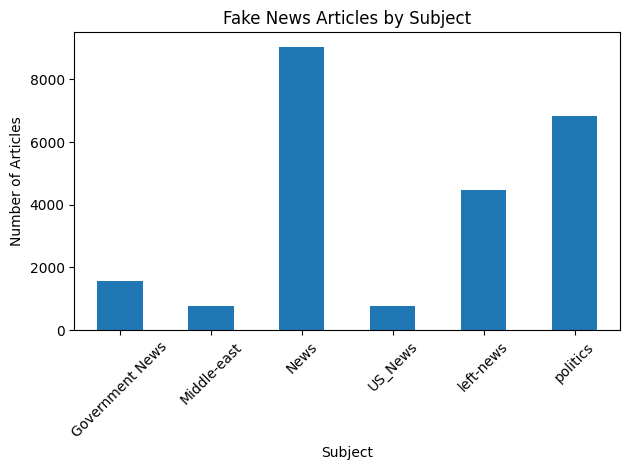

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Fake.csv.zip")


# 1. Create calculated field - Text Length

df["Text_Length"] = df["text"].astype(str).apply(len)


# 2. Group by Subject

subject_analysis = df.groupby("subject").agg(

    Total_Articles=("title", "count"),

    Average_Text_Length=("Text_Length", "mean")

)


print("Subject Analysis:")
print(subject_analysis)


# 3. News analysis by Subject

news_analysis = pd.crosstab(

    df["subject"],

    columns="Number of Articles"

)


print("\nNews by Subject:")
print(news_analysis)


# 4. Group by Date

# Convert date column to datetime

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Extract year

df["Year"] = df["date"].dt.year


year_analysis = df.groupby("Year").agg(

    Total_Articles=("title", "count"),

    Average_Text_Length=("Text_Length", "mean")

)


print("\nYear Analysis:")
print(year_analysis)


# 5. Bar Chart - Articles by Subject

subject_analysis["Total_Articles"].plot(

    kind="bar"
)


plt.title("Fake News Articles by Subject")

plt.xlabel("Subject")

plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()